# Model Training and Evaluation

After completing data preprocessing, feature engineering, and feature selection, machine learning models are trained to predict football match outcomes.

Since this is a multiclass classification problem, several classification algorithms are evaluated and compared. The models are assessed using common classification metrics to determine which one generalizes best to unseen data.

The following steps are performed:

1. Split the dataset into training and testing sets.
2. Train multiple classification models.
3. Evaluate each model using classification metrics.
4. Compare the performance of all models.

## Import Libraries

In [40]:
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import category_encoders as ce
from sklearn.metrics import (
    classification_report, 
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

## Load Dataset

In [41]:
df_selected = pd.read_csv("../data/engineered_data.csv")

## Train and Test Split

The dataset is divided into two subsets:

- **Training set (80%)** for training the models.
- **Test set (20%)** for evaluating the final model on unseen data.

Because football is a time-series event and our features rely on rolling historical averages, we must split the data chronologically. Randomly shuffling the data would cause "data leakage" (the model learning from future events to predict past events). 

Therefore, `shuffle=False` is used to ensure the model trains strictly on older matches and is tested on the most recent 20% of matches.

In [42]:
X = df_selected.drop(columns=["match_result"])
y = df_selected["match_result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False 
)
print(f"Training Set:   {X_train.shape}")
print(f"Test Set:       {X_test.shape}")

print("Encoding Categorical Features...")
cat_cols = ['home_club', 'away_club', 'competition']
te = ce.TargetEncoder(cols=cat_cols)

X_train_encoded = te.fit_transform(X_train, y_train)
X_test_encoded = te.transform(X_test)

print("Imputing Missing Values...")
imputer = SimpleImputer(strategy='median')

X_train_clean = pd.DataFrame(imputer.fit_transform(X_train_encoded), columns=X_train_encoded.columns)
X_test_clean = pd.DataFrame(imputer.transform(X_test_encoded), columns=X_test_encoded.columns)

print("Data is ready for modeling!")

Training Set:   (88736, 93)
Test Set:       (22185, 93)
Encoding Categorical Features...
Imputing Missing Values...
Data is ready for modeling!


## Logistic Regression

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

## Decision Tree

In [44]:
dt = DecisionTreeClassifier(random_state=50)

dt.fit(X_train_clean, y_train)

dt_pred = dt.predict(X_test_clean)

## Random Forest

In [45]:
rf = RandomForestClassifier(
    n_estimators=200,         
    class_weight="balanced",   
    random_state=50,
    n_jobs=-1
)

rf.fit(X_train_clean, y_train)
rf_pred = rf.predict(X_test_clean)

## KNN

In [46]:
scaler = StandardScaler()

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

## XGBoost Classifier

In [47]:
# # Calculate weights for the 'Draw' class imbalance
# sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# # Define the grid of parameters to test
# param_dist = {
#     'n_estimators': [200, 300, 400],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [4, 5, 6],
#     'subsample': [0.8, 1.0],         # Randomly drops rows to prevent overfitting
#     'colsample_bytree': [0.8, 1.0]   # Randomly drops columns to prevent overfitting
# }

# xgb_base = XGBClassifier(objective='multi:softprob', random_state=42)

# # Setup the Randomized Search
# random_search = RandomizedSearchCV(
#     estimator=xgb_base,
#     param_distributions=param_dist,
#     n_iter=10,                      # Tests 10 random combinations from the grid above
#     scoring='f1_weighted',          # Optimizes specifically for the F1-score
#     cv=3,                           # 3-fold cross-validation
#     random_state=42,
#     n_jobs=-1                       # Uses all CPU cores
# )

# # Fit the search (This will take a few minutes to run!)
# print("Tuning XGBoost... please wait.")
# random_search.fit(X_train_clean, y_train, sample_weight=sample_weights)

# print("Best Parameters found:", random_search.best_params_)

# # Make predictions using the best model found
# best_xgb = random_search.best_estimator_
# xgb_pred = best_xgb.predict(X_test_clean)

In [48]:
def evaluate(y_true, y_pred):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1": f1_score(y_true, y_pred, average="weighted")
    }

In [49]:
results = pd.DataFrame({
    "Logistic Regression": evaluate(y_test, lr_pred),
    "Decision Tree": evaluate(y_test, dt_pred),
    "Random Forest": evaluate(y_test, rf_pred),
    "KNN": evaluate(y_test, knn_pred),
    # "xgb": evaluate(y_test, xgb_pred)
}).T

results

,Accuracy,Precision,Recall,F1
Logistic Regression,0.463421,0.434351,0.463421,0.420149
Decision Tree,0.388145,0.391831,0.388145,0.389807
Random Forest,0.461077,0.444828,0.461077,0.449326
KNN,0.412125,0.416909,0.412125,0.411854


In [50]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.44      0.49      0.46      6958
           1       0.30      0.21      0.25      5750
           2       0.53      0.60      0.56      9477

    accuracy                           0.46     22185
   macro avg       0.43      0.43      0.42     22185
weighted avg       0.44      0.46      0.45     22185



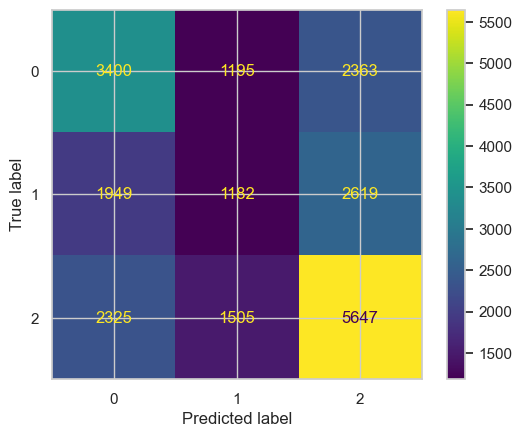

In [51]:
ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test_clean,
    y_test
)

In [ ]:
scores = cross_val_score(rf, X_train_clean, y_train, cv=5)

print("Cross-validation accuracy:", scores.mean())